# Lab 6, Part 1 — Transformer building blocks from scratch (and verified)

This notebook covers the six concepts listed in the lab handout:

1. the attention mechanism;
2. self-attention;
3. cross-attention;
4. multi-head attention;
5. positional encoding;
6. masked (causal) attention.

Each concept is implemented directly from its equation in plain PyTorch. The implementation is then **checked against PyTorch's own implementation**, or against a property the mathematics guarantees. Everything runs on the CPU in a few seconds.

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
torch.set_printoptions(precision=4, sci_mode=False)
print("torch", torch.__version__)

torch 2.14.0+cu130


## 1. The attention mechanism: scaled dot-product attention

$$
\mathrm{Attention}(Q,K,V)=\mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}+M\right)V
$$

* Each **query** $q_i$ is compared with every **key** $k_j$ using a dot product, which measures similarity.
* The scores are divided by $\sqrt{d_k}$. If the components of $q$ and $k$ have unit variance, the dot product $q\cdot k$ has variance $d_k$. Dividing restores unit variance, which stops the softmax from saturating and its gradients from vanishing.
* The softmax turns each row of scores into weights that are non-negative and sum to 1.
* The output for query $i$ is the **weighted average of the values**, $\sum_j \alpha_{ij} v_j$.
* $M$ is an optional additive mask. It is 0 where attention is allowed and $-\infty$ where it is blocked.

In [2]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    # Q: (..., n_q, d_k)   K: (..., n_k, d_k)   V: (..., n_k, d_v)
    # mask: boolean, True = allowed; broadcastable to (..., n_q, n_k)
    d_k = Q.size(-1)
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(~mask, float("-inf"))
    weights = scores.softmax(dim=-1)
    return weights @ V, weights


Q, K, V = torch.randn(2, 5, 8), torch.randn(2, 7, 8), torch.randn(2, 7, 16)
out, w = scaled_dot_product_attention(Q, K, V)
ref = F.scaled_dot_product_attention(Q, K, V)
print("output shape", tuple(out.shape), "| weights shape", tuple(w.shape))
print("rows of the weights sum to 1:", torch.allclose(w.sum(-1), torch.ones(2, 5)))
print("max |ours - torch|:", (out - ref).abs().max().item())

output shape (2, 5, 16) | weights shape (2, 5, 7)
rows of the weights sum to 1: True
max |ours - torch|: 2.086162567138672e-07


In [3]:
# Why divide by sqrt(d_k): variance of q.k grows like d_k
for d in [4, 64, 512]:
    q, k = torch.randn(10000, d), torch.randn(10000, d)
    dots = (q * k).sum(-1)
    print(f"d_k={d:4d}  var(q.k)={dots.var():8.1f}   var(q.k/sqrt(d_k))={(dots / math.sqrt(d)).var():.2f}")

# Unscaled scores become nearly one-hot, and the softmax gradient vanishes
d = 512
q, k = torch.randn(1, d), torch.randn(20, d)
for name, s in [("unscaled", q @ k.T), ("scaled", q @ k.T / math.sqrt(d))]:
    p = s.softmax(-1)
    print(f"{name:9s} max weight={p.max():.3f}   entropy={-(p * p.clamp_min(1e-12).log()).sum():.3f}")

d_k=   4  var(q.k)=     4.0   var(q.k/sqrt(d_k))=1.00
d_k=  64  var(q.k)=    63.6   var(q.k/sqrt(d_k))=0.99
d_k= 512  var(q.k)=   502.4   var(q.k/sqrt(d_k))=0.98
unscaled  max weight=1.000   entropy=0.000
scaled    max weight=0.208   entropy=2.693


## 2. Self-attention

In **self-attention**, $Q$, $K$ and $V$ all come from the **same** sequence $X$, through learned projections: $Q=XW_Q$, $K=XW_K$, $V=XW_V$. Each token builds its new representation from every token in the same sentence, including itself.

The toy example below shows why this is useful. The word *it* can learn to attend to *animal*, which resolves the reference. Here the weights are random, so we only check shapes and the core symmetry property. **Self-attention without positional information is permutation-equivariant**: shuffling the input tokens shuffles the outputs in exactly the same way. It has no notion of word order, and that is why Section 5 is needed.

In [4]:
class SelfAttention(nn.Module):
    def __init__(self, d_model, d_k):
        super().__init__()
        self.Wq = nn.Linear(d_model, d_k, bias=False)
        self.Wk = nn.Linear(d_model, d_k, bias=False)
        self.Wv = nn.Linear(d_model, d_k, bias=False)

    def forward(self, X, mask=None):
        return scaled_dot_product_attention(self.Wq(X), self.Wk(X), self.Wv(X), mask)


sa = SelfAttention(d_model=16, d_k=16)
X = torch.randn(1, 6, 16)                     # 6 tokens
Y, W = sa(X)

perm = torch.tensor([3, 0, 5, 1, 4, 2])
Y_perm, _ = sa(X[:, perm])
print("self-attention(permuted X) == permuted self-attention(X):",
      torch.allclose(Y_perm, Y[:, perm], atol=1e-6))

self-attention(permuted X) == permuted self-attention(X): True


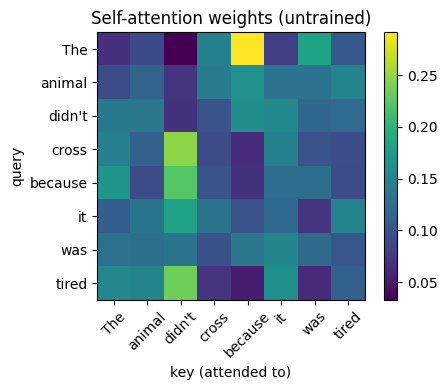

In [5]:
tokens = ["The", "animal", "didn't", "cross", "because", "it", "was", "tired"]
emb = nn.Embedding(len(tokens), 16)
with torch.no_grad():
    _, W = sa(emb(torch.arange(len(tokens)))[None])

plt.figure(figsize=(5, 4))
plt.imshow(W[0], cmap="viridis")
plt.xticks(range(len(tokens)), tokens, rotation=45)
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("key (attended to)"); plt.ylabel("query")
plt.title("Self-attention weights (untrained)")
plt.colorbar(); plt.tight_layout(); plt.show()

## 3. Cross-attention

In the encoder–decoder Transformer (the translation architecture in the handout's figure), each decoder layer contains **cross-attention**:

* **queries** come from the **decoder**, i.e. the target sequence generated so far (for example, French);
* **keys and values** come from the **encoder output**, i.e. the source sentence (for example, English).

So each target position looks up the most relevant source positions. This is a learned, soft word alignment. Source and target can have different lengths. The weight matrix has shape (target length × source length), and each of its rows sums to 1.

In [6]:
class CrossAttention(nn.Module):
    def __init__(self, d_model, d_k):
        super().__init__()
        self.Wq = nn.Linear(d_model, d_k, bias=False)
        self.Wk = nn.Linear(d_model, d_k, bias=False)
        self.Wv = nn.Linear(d_model, d_k, bias=False)

    def forward(self, decoder_states, encoder_states, mask=None):
        return scaled_dot_product_attention(self.Wq(decoder_states),
                                            self.Wk(encoder_states),
                                            self.Wv(encoder_states), mask)


enc = torch.randn(1, 4, 16)   # "I love machine learning"          (4 source tokens)
dec = torch.randn(1, 6, 16)   # "J' aime l' apprentissage automatique <eos>" (6 target tokens)
ca = CrossAttention(16, 16)
Y, W = ca(dec, enc)
print("output:", tuple(Y.shape), "(one vector per TARGET token)")
print("weights:", tuple(W.shape), "(target x source)")

# The output depends on the encoder only through K and V: changing one source token changes
# the outputs, and changing the decoder never changes which source tokens are available.
enc2 = enc.clone(); enc2[0, 2] += 1.0
print("changing a source token changes the outputs:", not torch.allclose(Y, ca(dec, enc2)[0]))

output: (1, 6, 16) (one vector per TARGET token)
weights: (1, 6, 4) (target x source)
changing a source token changes the outputs: True


## 4. Multi-head attention

$$
\mathrm{MultiHead}(Q,K,V)=\mathrm{Concat}(\mathrm{head}_1,\dots,\mathrm{head}_h)\,W_O,\qquad
\mathrm{head}_i=\mathrm{Attention}(QW_Q^{(i)},KW_K^{(i)},VW_V^{(i)})
$$

With $d_k = d_{model}/h$, the $h$ heads cost about the same as one full-width head. They can attend to **different relations at the same time**, such as syntax, coreference, or the neighbouring position. A single head has to average all of those into one distribution.

Below, our implementation is **checked against `torch.nn.MultiheadAttention`** by copying its weights into ours. The check covers self-attention, cross-attention and causal masking.

In [7]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.h, self.d_k = n_heads, d_model // n_heads
        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)
        self.Wo = nn.Linear(d_model, d_model)

    def split(self, x):                        # (B, n, d_model) -> (B, h, n, d_k)
        B, n, _ = x.shape
        return x.view(B, n, self.h, self.d_k).transpose(1, 2)

    def forward(self, q_in, kv_in, mask=None):
        Q, K, V = self.split(self.Wq(q_in)), self.split(self.Wk(kv_in)), self.split(self.Wv(kv_in))
        out, weights = scaled_dot_product_attention(Q, K, V, mask)   # (B, h, n_q, d_k)
        B, _, n_q, _ = out.shape
        out = out.transpose(1, 2).reshape(B, n_q, self.h * self.d_k)   # concatenate heads
        return self.Wo(out), weights


def load_from_torch(mine, theirs):
    d = mine.Wq.in_features
    Wq, Wk, Wv = theirs.in_proj_weight.split(d)
    bq, bk, bv = theirs.in_proj_bias.split(d)
    with torch.no_grad():
        for lin, W, b in [(mine.Wq, Wq, bq), (mine.Wk, Wk, bk), (mine.Wv, Wv, bv)]:
            lin.weight.copy_(W); lin.bias.copy_(b)
        mine.Wo.weight.copy_(theirs.out_proj.weight); mine.Wo.bias.copy_(theirs.out_proj.bias)


d_model, h = 32, 4
torch_mha = nn.MultiheadAttention(d_model, h, batch_first=True)
my_mha = MultiHeadAttention(d_model, h)
load_from_torch(my_mha, torch_mha)

x = torch.randn(2, 10, d_model); mem = torch.randn(2, 7, d_model)
causal = torch.tril(torch.ones(10, 10, dtype=torch.bool))

tests = {
    "self-attention":  (my_mha(x, x)[0],               torch_mha(x, x, x)[0]),
    "cross-attention": (my_mha(x, mem)[0],             torch_mha(x, mem, mem)[0]),
    "causal self-att": (my_mha(x, x, causal)[0],       torch_mha(x, x, x, attn_mask=~causal)[0]),
}
for name, (a, b) in tests.items():
    print(f"{name:16s} max |ours - nn.MultiheadAttention| = {(a - b).abs().max().item():.2e}")
    assert torch.allclose(a, b, atol=1e-5)

self-attention   max |ours - nn.MultiheadAttention| = 8.94e-08
cross-attention  max |ours - nn.MultiheadAttention| = 8.94e-08
causal self-att  max |ours - nn.MultiheadAttention| = 8.94e-08


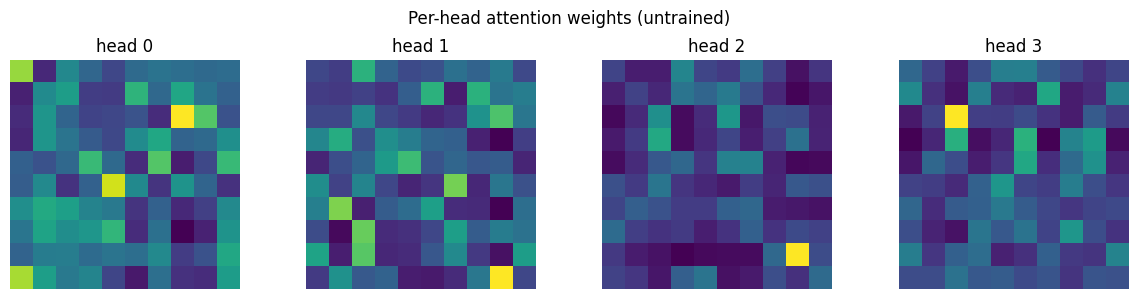

In [8]:
# Different heads produce different attention patterns over the same sentence
with torch.no_grad():
    _, W = my_mha(x[:1], x[:1])
fig, axes = plt.subplots(1, h, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(W[0, i], cmap="viridis"); ax.set_title(f"head {i}"); ax.axis("off")
plt.suptitle("Per-head attention weights (untrained)"); plt.tight_layout(); plt.show()

## 5. Positional encoding

Section 2 showed that attention ignores order. The original Transformer therefore **adds** a fixed sinusoidal vector to each token embedding:

$$
PE_{(pos,2i)}=\sin\!\left(\frac{pos}{10000^{2i/d}}\right),\qquad
PE_{(pos,2i+1)}=\cos\!\left(\frac{pos}{10000^{2i/d}}\right)
$$

Each pair of dimensions is a sine/cosine clock at a different frequency, running from fast (i = 0) to very slow. The key property is that for any offset $k$, $PE_{pos+k}$ is a **fixed linear function (a rotation) of $PE_{pos}$** that does not depend on $pos$. Relative positions are therefore easy to express with the linear maps inside attention. The code below checks this numerically, and also checks that adding PE breaks the permutation equivariance from Section 2.

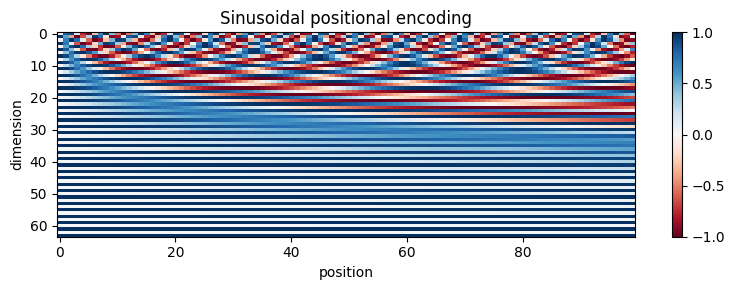

max |R_k PE[pos] - PE[pos+k]| over all pos: 4.97e-06  (same R_k for every pos)
with PE, permuting the words changes more than the order of the outputs: True


In [9]:
def sinusoidal_pe(n_pos, d):
    pos = torch.arange(n_pos).unsqueeze(1).float()
    i = torch.arange(0, d, 2).float()
    freq = 1.0 / (10000 ** (i / d))
    pe = torch.zeros(n_pos, d)
    pe[:, 0::2] = torch.sin(pos * freq)
    pe[:, 1::2] = torch.cos(pos * freq)
    return pe, freq


pe, freq = sinusoidal_pe(100, 64)
plt.figure(figsize=(8, 3))
plt.imshow(pe.T, aspect="auto", cmap="RdBu"); plt.xlabel("position"); plt.ylabel("dimension")
plt.title("Sinusoidal positional encoding"); plt.colorbar(); plt.tight_layout(); plt.show()

# Relative-position property: PE[pos+k] = R_k @ PE[pos], with R_k block-diagonal 2x2 rotations
k = 5
R = torch.zeros(64, 64)
for j, w in enumerate(freq):
    c, s = math.cos(k * w), math.sin(k * w)
    R[2*j:2*j+2, 2*j:2*j+2] = torch.tensor([[c, s], [-s, c]])
err = max((R @ pe[p] - pe[p + k]).abs().max().item() for p in range(90))
print(f"max |R_k PE[pos] - PE[pos+k]| over all pos: {err:.2e}  (same R_k for every pos)")

# Positional encoding breaks permutation equivariance
Xp = X + sinusoidal_pe(6, 16)[0]
Y1, _ = sa(Xp)
Y2, _ = sa(X[:, perm] + sinusoidal_pe(6, 16)[0])
print("with PE, permuting the words changes more than the order of the outputs:",
      not torch.allclose(Y2, Y1[:, perm], atol=1e-5))

## 6. Masked (causal) attention

A decoder generates text left to right. During training, the whole target sentence is fed in at once, shifted right by one position ("teacher forcing"). A **causal mask** stops position $t$ from seeing positions $> t$. Without it, the model could simply copy the next token it is supposed to predict.

The mask is lower-triangular. Blocked scores are set to $-\infty$, so they become exactly 0 after the softmax. The test below changes a *future* token and confirms that the outputs for all earlier positions stay the same.

tensor([[1, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1]], dtype=torch.int32)

weights above the diagonal are exactly zero: True
outputs 0..3 unchanged: True
outputs 4..5 changed:   True
WITHOUT the mask, output 0 changes too (information leaks from the future): True


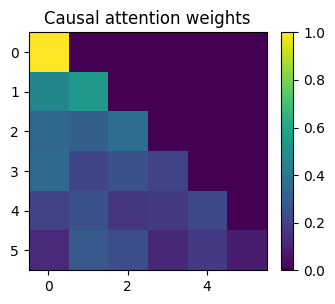

In [10]:
n = 6
causal = torch.tril(torch.ones(n, n, dtype=torch.bool))
print(causal.int())

X = torch.randn(1, n, 16)
Y, W = sa(X, causal)
print("\nweights above the diagonal are exactly zero:", bool((W[0].triu(1) == 0).all()))

X2 = X.clone(); X2[0, 4] = torch.randn(16)          # change token 4 (the "future" for positions 0-3)
Y2, _ = sa(X2, causal)
print("outputs 0..3 unchanged:", torch.allclose(Y[0, :4], Y2[0, :4]))
print("outputs 4..5 changed:  ", not torch.allclose(Y[0, 4:], Y2[0, 4:]))

Yu, _ = sa(X); Yu2, _ = sa(X2)
print("WITHOUT the mask, output 0 changes too (information leaks from the future):",
      not torch.allclose(Yu[0, 0], Yu2[0, 0]))

plt.figure(figsize=(3.5, 3)); plt.imshow(W[0].detach(), cmap="viridis")
plt.title("Causal attention weights"); plt.colorbar(); plt.tight_layout(); plt.show()

## Putting it together: encoder and decoder layers

The handout's figure uses post-norm residual blocks. The encoder layer is self-attention followed by a feed-forward network. The decoder layer is masked self-attention, then cross-attention, then a feed-forward network. Each sub-layer is followed by "Add & Norm". The code below assembles those layers from the pieces above and checks the shapes of a full translation-style forward pass.

In [11]:
class EncoderLayer(nn.Module):
    def __init__(self, d, h, d_ff):
        super().__init__()
        self.att = MultiHeadAttention(d, h)
        self.ff = nn.Sequential(nn.Linear(d, d_ff), nn.ReLU(), nn.Linear(d_ff, d))
        self.n1, self.n2 = nn.LayerNorm(d), nn.LayerNorm(d)

    def forward(self, x):
        x = self.n1(x + self.att(x, x)[0])
        return self.n2(x + self.ff(x))


class DecoderLayer(nn.Module):
    def __init__(self, d, h, d_ff):
        super().__init__()
        self.self_att, self.cross_att = MultiHeadAttention(d, h), MultiHeadAttention(d, h)
        self.ff = nn.Sequential(nn.Linear(d, d_ff), nn.ReLU(), nn.Linear(d_ff, d))
        self.n1, self.n2, self.n3 = nn.LayerNorm(d), nn.LayerNorm(d), nn.LayerNorm(d)

    def forward(self, y, memory, causal):
        y = self.n1(y + self.self_att(y, y, causal)[0])     # masked multi-head self-attention
        y = self.n2(y + self.cross_att(y, memory)[0])       # queries: decoder; keys/values: encoder
        return self.n3(y + self.ff(y))


d, V_src, V_tgt = 32, 50, 60
src_emb, tgt_emb = nn.Embedding(V_src, d), nn.Embedding(V_tgt, d)
encoder, decoder = EncoderLayer(d, 4, 64), DecoderLayer(d, 4, 64)
to_logits = nn.Linear(d, V_tgt)

src = torch.randint(0, V_src, (2, 4))      # batch of 2 source sentences, 4 tokens
tgt = torch.randint(0, V_tgt, (2, 6))      # shifted target, 6 tokens
memory = encoder(src_emb(src) + sinusoidal_pe(4, d)[0])
causal = torch.tril(torch.ones(6, 6, dtype=torch.bool))
dec_out = decoder(tgt_emb(tgt) + sinusoidal_pe(6, d)[0], memory, causal)
probs = to_logits(dec_out).softmax(-1)
print("memory:", tuple(memory.shape), " decoder out:", tuple(dec_out.shape), " output probs:", tuple(probs.shape))
print("each position is a distribution over the target vocabulary:", torch.allclose(probs.sum(-1), torch.ones(2, 6)))

memory: (2, 4, 32)  decoder out: (2, 6, 32)  output probs: (2, 6, 60)
each position is a distribution over the target vocabulary: True


## Encoder-only vs decoder-only vs encoder–decoder

| Family | Example | Attention used | Typical use (from the handout) |
|---|---|---|---|
| Encoder–decoder | original Transformer, T5, MarianMT | encoder: bidirectional self-attention; decoder: **masked** self-attention + **cross**-attention | translation and other sequence-to-sequence tasks |
| Encoder-only | BERT | bidirectional self-attention, **no mask**: every token sees the whole input | understanding and representation: semantic search, retrieval, clustering, classification such as sentiment |
| Decoder-only | GPT, Llama, Qwen | **masked** self-attention only, no cross-attention | generation: chat, code, summarisation, question answering |

An encoder produces a contextual vector for every input token, which is why it suits embeddings and classification. A decoder only ever looks left, which is exactly the condition for predicting the next token autoregressively.